In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

rows = []
start_time = datetime.now()

for i in range(10000):  # simulate ~5–7 days
    timestamp = start_time + timedelta(seconds=i*30)

    temperature = np.random.normal(30, 3)  # normal temp
    air_quality = np.random.randint(200, 400)
    heart_rate = np.random.normal(75, 10)

    # introduce anomalies
    if np.random.rand() < 0.02:
        temperature += np.random.randint(10, 20)
    if np.random.rand() < 0.02:
        heart_rate += np.random.randint(50, 80)

    rows.append([
        timestamp,
        "Device_1776850376944",
        round(temperature,2),
        air_quality,
        round(heart_rate,2),
        6.9271,  # sample coords
        79.8612
    ])

df = pd.DataFrame(rows, columns=[
    "timestamp","sensor_id","temperature",
    "air_quality","heart_rate","latitude","longitude"
])

df.to_csv("iot_dataset.csv", index=False)
print("Dataset generated!")

Dataset generated!


In [2]:
from sklearn.linear_model import LinearRegression

df['time_index'] = range(len(df))

X = df[['time_index']]
y = df['temperature']

model = LinearRegression()
model.fit(X, y)

print("Trend Coefficient:", model.coef_)

Trend Coefficient: [7.63681148e-07]


In [3]:
from sklearn.ensemble import IsolationForest

features = df[['temperature','air_quality','heart_rate']]

model = IsolationForest(contamination=0.02)
df['anomaly'] = model.fit_predict(features)

# -1 = anomaly, 1 = normal

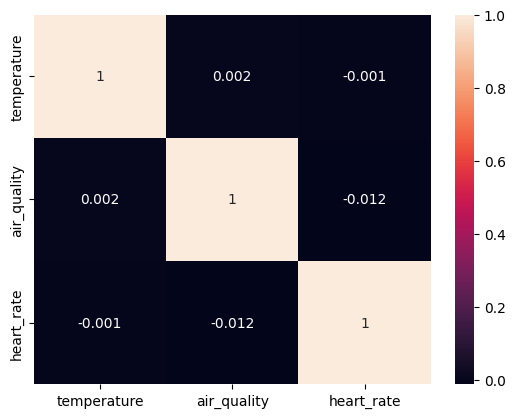

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['temperature','air_quality','heart_rate']].corr()

sns.heatmap(corr, annot=True)
plt.show()